In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn import metrics, model_selection


In [2]:
train = pd.read_csv("../artifacts/feature_engineering/features_train.csv")
test = pd.read_csv("../artifacts/feature_engineering/features_test.csv")

target = "log_price"

In [3]:
X_train = train.drop(columns=target)
y_train = train[target]

X_test = test.drop(columns=target)
y_test = test[target]


In [4]:
model = XGBRegressor()
model = model.fit(X_train, y_train)

In [5]:
def compute_metrics(model, x, y, cv=5):
    preds = model.predict(x)
    score = model.score(x, y)

    scores_cvs = model_selection.cross_val_score(model, x, y, scoring="r2", cv=cv)

    return pd.DataFrame(
        [
            {
                "R2": round(score, 3),
                "mse": round(metrics.mean_squared_error(y, preds), 3),
                "rmse": round(np.sqrt(metrics.mean_squared_error(y, preds)), 3),
                "mae": round(metrics.mean_absolute_error(y, preds), 3),
                "adjusted_r2": round(
                    1 - (1 - score) * (len(y) - 1) / (len(y) - x.shape[1] - 1), 3
                ),
                "cv_score": round(scores_cvs.mean() * 100, 2),
            }
        ]
    )


In [6]:
val_metrics = compute_metrics(model, X_test, y_test)
val_metrics


,R2,mse,rmse,mae,adjusted_r2,cv_score
0,0.842,0.225,0.474,0.348,0.842,80.98


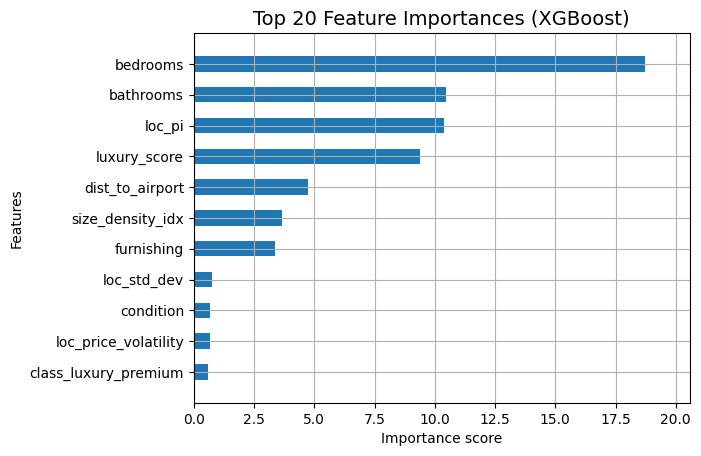

In [7]:
# Plot importances
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(
    model,
    importance_type="gain",
    max_num_features=20,
    height=0.5,
    show_values=False,
)
plt.title("Top 20 Feature Importances (XGBoost)", fontsize=14)
plt.show()
